# 사주 AI Agent — LangGraph 그래프 실행 테스트

In [6]:
import sys
from pathlib import Path

# notebook/ 한 단계 위가 backend 루트
BACKEND_ROOT = Path.cwd().parent
sys.path.insert(0, str(BACKEND_ROOT))

from dotenv import load_dotenv
load_dotenv(BACKEND_ROOT / ".env")

import os
print("OPENAI_API_KEY:", "✅" if os.getenv("OPENAI_API_KEY") else "❌ 없음")

OPENAI_API_KEY: ✅


## 1. 그래프 컴파일 & 시각화

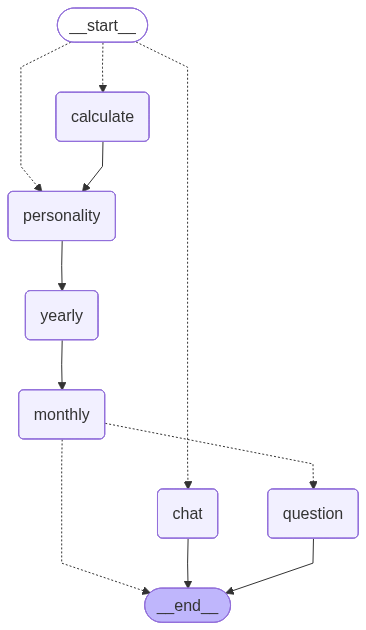

In [7]:
from langgraph.checkpoint.memory import MemorySaver
from app.agent.graph.builder import _build_graph
from IPython.display import Image, display

# MemorySaver로 컴파일 (PostgreSQL 없이 로컬 테스트)
graph = _build_graph().compile(checkpointer=MemorySaver())

# LangGraph 내장 시각화 — PNG 렌더링
display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 테스트 입력 상태 세팅

In [8]:
import uuid

TEST_STATE = {
    # ── 사용자 입력 ────────────────────────────────
    "birth_date":    "1997-03-15",       # YYYY-MM-DD (수정 가능)
    "birth_time":    "14:30",            # HH:MM | 미상
    "gender":        "M",               # M / F
    "calendar_type": "solar",           # solar / lunar
    "name":          "홍길동",
    "relationship":  "솔로",
    "question":      "올해 이직해도 될까요?",  # 비워두면 question 노드 스킵

    # ── 그래프 내부 상태 초기값 ─────────────────────
    "saju_data":     None,              # None → calculate 노드부터 시작
    "messages":      [],
}

THREAD_ID = str(uuid.uuid4())
CONFIG    = {"configurable": {"thread_id": THREAD_ID}}

print("테스트 설정 완료")
print(f"  이름:     {TEST_STATE['name']}")
print(f"  생년월일:  {TEST_STATE['birth_date']} ({TEST_STATE['gender']} / {TEST_STATE['calendar_type']})")
print(f"  시간:     {TEST_STATE['birth_time']}")
print(f"  질문:     {TEST_STATE['question']}")
print(f"  thread_id: {THREAD_ID[:8]}…")

테스트 설정 완료
  이름:     홍길동
  생년월일:  1997-03-15 (M / solar)
  시간:     14:30
  질문:     올해 이직해도 될까요?
  thread_id: 658a2419…


## 3. astream 실행 — 노드별 결과 확인

In [9]:
import textwrap, time

ICON = {
    "calculate":   "🧮",
    "personality": "🌿",
    "yearly":      "📅",
    "monthly":     "🗓",
    "question":    "🔮",
    "chat":        "💬",
}

print(f"{'='*64}")
print(f"  🚀 astream 시작")
print(f"{'='*64}\n")

t0 = time.perf_counter()

async for chunk in graph.astream(TEST_STATE, CONFIG):
    node = next(iter(chunk))
    data = chunk[node]
    elapsed = time.perf_counter() - t0

    print(f"{ICON.get(node,'▶')} [{elapsed:5.1f}s] {node}")
    print(f"{'─'*56}")

    for key, val in data.items():

        if isinstance(val, str) and val:
            wrapped = textwrap.fill(val, width=72,
                                    initial_indent="    ",
                                    subsequent_indent="    ")
            print(f"  ▸ {key}:")
            print(wrapped)

        elif isinstance(val, dict):
            print(f"  ▸ {key}:")
            for sub_key, sub_val in val.items():
                if isinstance(sub_val, str):
                    preview = textwrap.shorten(sub_val, width=80, placeholder="…")
                    print(f"      [{sub_key}] {preview}")
                elif isinstance(sub_val, dict):
                    # saju_data 안의 pillar dict 등
                    inner = " / ".join(f"{k}={v}" for k, v in sub_val.items()
                                       if isinstance(v, str))
                    print(f"      [{sub_key}] {{ {inner[:60]} }}")
                else:
                    print(f"      [{sub_key}] {sub_val}")

        elif isinstance(val, list):
            print(f"  ▸ {key}: (list {len(val)}개)")

        elif val is not None:
            print(f"  ▸ {key}: {val}")

    print()

print(f"{'='*64}")
print(f"  ✅ 완료  총 소요: {time.perf_counter()-t0:.1f}s")
print(f"{'='*64}")

  🚀 astream 시작

🧮 [  0.0s] calculate
────────────────────────────────────────────────────────
  ▸ saju_data:
      [year_pillar] { gan=丁 / zhi=丑 / gan_kr=정 / zhi_kr=축 / gan_wuxing=火 / zhi_wux }
      [month_pillar] { gan=癸 / zhi=卯 / gan_kr=계 / zhi_kr=묘 / gan_wuxing=水 / zhi_wux }
      [day_pillar] { gan=甲 / zhi=寅 / gan_kr=갑 / zhi_kr=인 / gan_wuxing=木 / zhi_wux }
      [hour_pillar] { gan=辛 / zhi=未 / gan_kr=신 / zhi_kr=미 / gan_wuxing=金 / zhi_wux }
      [day_gan] 甲
      [day_gan_wuxing] 木
      [yearly_fortune] { gan=丙 / zhi=午 / gan_kr=병 / zhi_kr=오 / gan_wuxing=火 / zhi_wux }
      [monthly_fortune] { gan=壬 / zhi=辰 / gan_kr=임 / zhi_kr=진 / gan_wuxing=水 / zhi_wux }
      [daeun] [{'gan': '壬', 'zhi': '寅', 'gan_kr': '임', 'zhi_kr': '인', 'gan_wuxing': '水', 'zhi_wuxing': '木', 'sipsung': '편인'}, {'gan': '辛', 'zhi': '丑', 'gan_kr': '신', 'zhi_kr': '축', 'gan_wuxing': '金', 'zhi_wuxing': '土', 'sipsung': '정관'}, {'gan': '庚', 'zhi': '子', 'gan_kr': '경', 'zhi_kr': '자', 'gan_wuxing': '金', 'zhi_wuxing': '水', '

## 4. 최종 State 전문 확인 (체크포인트 복원)

In [10]:
snapshot = await graph.aget_state(CONFIG)
s = snapshot.values

# ── 사주팔자 ──────────────────────────────────────────────────────────────────
if s.get("saju_data"):
    sd = s["saju_data"]
    pillars = ["year_pillar", "month_pillar", "day_pillar", "hour_pillar"]
    labels  = ["년주", "월주", "일주", "시주"]
    print("[ 사주팔자 ]")
    for p, l in zip(pillars, labels):
        d = sd[p]
        print(f"  {l}: {d['gan']}{d['zhi']} ({d['gan_kr']}{d['zhi_kr']} / {d['gan_wuxing']}{d['zhi_wuxing']})")
    oe = sd["ohaeng_scores"]
    print(f"  오행: 木{oe['wood']} 火{oe['fire']} 土{oe['earth']} 金{oe['metal']} 水{oe['water']}")
    print()

# ── AI 분석 결과 ───────────────────────────────────────────────────────────────
for key, label in [
    ("personality_analysis", "[ 기질·성격 분석 ]"),
    ("yearly_fortune",       "[ 신년운세 ]"),
    ("question_answer",      "[ 질문 답변 ]"),
]:
    val = s.get(key)
    if val:
        print(label)
        print(textwrap.fill(val, width=72,
                            initial_indent="  ",
                            subsequent_indent="  "))
        print()

# ── 월운 (5개 카테고리) ────────────────────────────────────────────────────────
mf = s.get("monthly_fortune")
if mf:
    print("[ 이번달 운세 ]")
    for cat in ["총운", "연애운", "재물운", "직업운", "사업운"]:
        val = mf.get(cat, "")
        if val:
            print(f"\n  [{cat}]")
            print(textwrap.fill(val, width=70,
                                initial_indent="    ",
                                subsequent_indent="    "))

[ 사주팔자 ]
  년주: 丁丑 (정축 / 火土)
  월주: 癸卯 (계묘 / 水木)
  일주: 甲寅 (갑인 / 木木)
  시주: 辛未 (신미 / 金土)
  오행: 木3 火1 土2 金1 水1

[ 기질·성격 분석 ]
  1. 융통성 — 이 사주에서 나무의 기운이 강해 다양한 상황에 유연하게 대처하고 적응하는 능력이 뛰어납니다.  2. 강점:
  타인의 감정을 잘 파악하여 팀 내에서 갈등을 중재하는 능력이 뛰어납니다. 또한, 계획을 세울 때 세부적인 부분까지 세심하게
  고려하여 진행하는 경향이 있어 프로젝트 매니지먼트에 강점을 발휘합니다.  3. 약점: 책임감이 무겁게 느껴질 때, 혼자
  해결하려는 경향이 있어 주변의 도움을 받지 못하는 경우가 잦습니다. 또한, 지나치게 완벽을 추구하여 스스로 스트레스를
  가중시키는 패턴을 보입니다.  4. 잘 맞는 직업·역할: 심리 상담사·조직 관리자·교사처럼 사람들과의 소통과 관계 형성이
  중요한 직군에서 두각을 나타냅니다. 이들은 적절한 조언과 방향성을 제시하는 데 능숙합니다.  5. 부족한 오행(없음 (균형
  잡힌 사주)) 채우는 법: 필요하지 않습니다. 그러나 생활의 활력을 위해 녹색 계열의 식물을 가까이 두고, 자연 속에서
  산책하는 습관을 가지면 더욱 긍정적 영향을 받을 수 있습니다.

[ 신년운세 ]
  1. 총운: 올해는 불의 기운이 강해지며 작년보다 더 활기차고 적극적인 한 해가 될 가능성이 큽니다. 특히 상반기에는 추진력이
  강해지고 새로운 프로젝트나 목표를 설정하기에 유리한 시기입니다. 반면, 하반기에는 다소 에너지가 소진될 수 있으니, 상반기에
  집중적으로 계획을 실행하는 것이 바람직합니다.  2. 기회의 영역: 올해는 커리어 전환에 좋은 기회가 있습니다. 불의 기운이
  강해지면서 창의적이고 도전적인 프로젝트에 참여할 때 성과를 보일 가능성이 큽니다. 특히 새로운 팀이나 조직에서의 역할 변화가
  예상되며, 이전보다 더 큰 책임을 맡게 될 수 있습니다.  3. 주의할 상황: 건강 면에서 무리